<a href="https://colab.research.google.com/github/gabrielbarata/MVP-machine-learning/blob/main/MVP_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, subprocess

path = '/usr/local/bin/cloudflared'
if os.path.exists(path):
    print("✓ cloudflared encontrado.")
    # Testar execução
    try:
        result = subprocess.run([path, '--version'], capture_output=True, text=True, timeout=5)
        print("Versão:", result.stdout.strip())
    except Exception as e:
        print("Erro ao executar:", e)
else:
    print("✗ cloudflared não encontrado. Instalando...")
    !curl -sL https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -o /usr/local/bin/cloudflared
    !chmod +x /usr/local/bin/cloudflared
    print("Instalação concluída. Execute esta célula novamente para testar.")

✓ cloudflared encontrado.
Versão: cloudflared version 2026.6.1 (built 2026-06-18-14:33 UTC)


In [ ]:
import subprocess, time, re, os, requests, signal
from flask import Flask, jsonify, request
from threading import Thread
from werkzeug.serving import make_server

# 0. Limpeza: mata apenas os processos de tunelamento ativos
os.system('pkill -f "cloudflared tunnel"')

# 1. Garantir que o serviço de teste está rodando na porta 5000
http_server = None

def setup_test_service():
    global http_server
    # Tenta matar o servidor anterior via requisição antes de começar
    try:
        requests.get('http://127.0.0.1:5000/shutdown', timeout=1)
        print("Sinal de desligamento enviado ao serviço anterior.")
        time.sleep(2)
    except:
        pass

    try:
        res = requests.get('http://127.0.0.1:5000/', timeout=1)
        print("✓ Serviço de teste já detectado na porta 5000.")
    except:
        print("! Iniciando novo serviço de teste na porta 5000...")
        app = Flask('test_service')

        @app.route('/')
        def index():
            return jsonify({"status": "ok", "message": "Cloudflare Tunnel Working", "pid": os.getpid()})

        @app.route('/shutdown')
        def shutdown():
            global http_server
            if http_server:
                Thread(target=http_server.shutdown).start()
            return 'Serviço encerrado com sucesso.'

        def run():
            global http_server
            http_server = make_server('127.0.0.1', 5000, app)
            http_server.serve_forever()

        Thread(target=run, daemon=True).start()
        time.sleep(2)

setup_test_service()

def start_tunnel():
    cmd = ['/usr/local/bin/cloudflared', 'tunnel', '--url', 'http://127.0.0.1:5000', '--no-autoupdate']
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    url = None
    start_time = time.time()
    while time.time() - start_time < 20:
        line = proc.stdout.readline()
        if not line: break
        match = re.search(r'https://[-\w]+\.trycloudflare\.com', line)
        if match:
            url = match.group(0)
            break
    return proc, url

# 2. Loop de verificação: Privado -> Público
working = False
while not working:
    # Teste Privado
    try:
        priv_check = requests.get('http://127.0.0.1:5000/', timeout=2)
        if priv_check.status_code != 200: raise Exception("Porta 5000 não responde 200 OK")
    except Exception as e:
        print(f"❌ Erro no teste privado: {e}. Certifique-se que o serviço Flask subiu.")
        time.sleep(5)
        continue

    proc, public_url = start_tunnel()

    if public_url:
        print(f"\nTentando validar link público: {public_url}")
        time.sleep(7) # Tempo para o DNS propagar
        try:
            res = requests.get(public_url, timeout=12)
            if res.status_code == 200:
                print(f"✅ SUCESSO! O link público está funcionando: {public_url}")
                working = True
            else:
                print(f"❌ Link público retornou status {res.status_code}. Reiniciando túnel...")
                os.kill(proc.pid, signal.SIGTERM)
        except Exception as e:
            print(f"⚠ Erro no link público ({e}). Reiniciando túnel...")
            os.kill(proc.pid, signal.SIGTERM)
    else:
        print("Falha ao obter URL do Cloudflare. Tentando novamente...")
        os.kill(proc.pid, signal.SIGTERM)
        time.sleep(5)

# 3. Chamada de encerramento
if working:
    print("\nEncerrando o serviço via endpoint...")
    try:
        shutdown_res = requests.get(f"http://127.0.0.1:5000/shutdown", timeout=5)
        print(f"Saída do endpoint: {shutdown_res.text}")
    except Exception as e:
        print(f"Erro ao chamar shutdown: {e}")

! Iniciando novo serviço de teste na porta 5000...


INFO:werkzeug:127.0.0.1 - - [01/Jul/2026 12:54:57] "GET / HTTP/1.1" 200 -



Tentando validar link público: https://bride-fee-oral-semiconductor.trycloudflare.com


INFO:werkzeug:127.0.0.1 - - [01/Jul/2026 12:55:09] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [01/Jul/2026 12:55:09] "GET /shutdown HTTP/1.1" 200 -


✅ SUCESSO! O link público está funcionando: https://bride-fee-oral-semiconductor.trycloudflare.com

Encerrando o serviço via endpoint...
Saída do endpoint: Serviço encerrado com sucesso.


In [ ]:
try:
  from flask_compress import Compress
except ModuleNotFoundError as e:
  !pip install flask-compress -q
  from flask_compress import Compress

In [ ]:
import os
import socket
import time
import logging
import requests
from threading import Thread
from io import BytesIO
from flask import Flask, send_file, request, jsonify, send_from_directory, make_response
from flask_compress import Compress
from werkzeug.serving import make_server
from PIL import Image, ImageDraw, ImageFont

logging.getLogger('werkzeug').setLevel(logging.ERROR)

server = Flask(__name__)

# ------------------------------------------------------------
# IMPORTANTE: nunca comprimir binários (PNG já é comprimido).
# Comprimir imagem gasta CPU à toa e não ganha nada em tamanho.
# Só vale a pena comprimir texto/HTML/JSON.
# ------------------------------------------------------------
server.config['COMPRESS_MIMETYPES'] = [
    'text/html', 'text/css', 'text/xml',
    'application/json', 'application/javascript', 'text/javascript'
]
Compress(server)

# ------------------------------------------------------------
# Funções utilitárias (fonte e placeholder)
# ------------------------------------------------------------
def _load_font(size=40):
    """Carrega uma fonte TrueType com suporte a acentos."""
    paths = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSans.ttf",
        "C:\\Windows\\Fonts\\arial.ttf"
    ]
    for p in paths:
        if os.path.exists(p):
            try:
                return ImageFont.truetype(p, size)
            except Exception:
                continue
    return ImageFont.load_default()

def _generate_placeholder_bytes(text="Aguardando..."):
    """Gera a imagem placeholder com borda preta e texto centralizado."""
    font = _load_font(40)
    try:
        img = Image.new('RGB', (800, 400), (240, 240, 240))
        draw = ImageDraw.Draw(img)
        draw.rectangle([0, 0, img.width - 1, img.height - 1], outline=(0, 0, 0), width=2)
        bbox = draw.textbbox((0, 0), text, font=font)
        text_width = bbox[2] - bbox[0]
        text_height = bbox[3] - bbox[1]
        x = (800 - text_width) / 2
        y = (400 - text_height) / 2
        draw.text((x, y), text, fill=(100, 100, 100), font=font)
    except Exception:
        img = Image.new('RGB', (800, 400), (240, 240, 240))
        draw = ImageDraw.Draw(img)
        draw.rectangle([0, 0, img.width - 1, img.height - 1], outline=(0, 0, 0), width=2)

    buf = BytesIO()
    img.save(buf, format='PNG')
    return buf.getvalue()

_placeholder_bytes = _generate_placeholder_bytes("Aguardando...")

def serve_placeholder():
    response = make_response(_placeholder_bytes)
    response.headers['Content-Type'] = 'image/png'
    response.headers['Cache-Control'] = 'no-store, no-cache, must-revalidate, max-age=0'
    response.headers['Pragma'] = 'no-cache'
    response.headers['Expires'] = '0'
    response.headers.pop('ETag', None)
    response.headers.pop('Last-Modified', None)
    return response

# ------------------------------------------------------------
# Helper genérico: hash leve baseado em mtime
# ------------------------------------------------------------
def get_file_hash(path):
    if not os.path.exists(path):
        return 'placeholder'
    return str(os.path.getmtime(path))

def cached_response(content, mimetype, timeout=5):
    response = make_response(content)
    response.headers['Content-Type'] = mimetype
    response.headers['Cache-Control'] = f'public, max-age={timeout}'
    return response

# ------------------------------------------------------------
# Rotas
# ------------------------------------------------------------
@server.route('/')
def home():
    html = """
    <!DOCTYPE html>
    <html lang="pt-br">
    <head>
        <meta charset="UTF-8">
        <title>AI Dashboard</title>
        <style>
            * { box-sizing: border-box; }
            body { font-family: system-ui, -apple-system, sans-serif; margin: 0; display: flex; height: 100vh; background: #f4f7f6; overflow: hidden; }
            #sidebar { width: 220px; background: #1a252f; color: white; display: flex; flex-direction: column; padding: 15px 0; }
            #sidebar h2 { text-align: center; font-size: 1rem; color: #3498db; margin-bottom: 20px; }
            .nav-item { padding: 12px 20px; cursor: pointer; transition: 0.2s; color: #bdc3c7; text-decoration: none; font-size: 0.9rem; border-left: 3px solid transparent; }
            .nav-item:hover { background: #2c3e50; color: white; }
            .nav-item.active { background: #2c3e50; border-left-color: #3498db; color: white; }
            #main-content { flex: 1; padding: 15px; display: flex; flex-direction: column; position: relative; }
            .viewer { width: 100%; height: 100%; border: none; background: white; border-radius: 4px; box-shadow: 0 1px 3px rgba(0,0,0,0.1); }
            pre { background: #272822; color: #f8f8f2; padding: 15px; border-radius: 4px; overflow: auto; margin: 0; font-size: 0.85rem; height: 100%; }

            .image-view { position: relative; width: 100%; height: 100%; overflow: hidden; }
            .img-viewer-wrapper { position: absolute; top: 0; left: 0; right: 0; bottom: 0; overflow: auto; background: #eee; border-radius: 4px; }
            .img-container {
                display: flex;
                justify-content: flex-start;
                align-items: flex-start;
                min-width: 100%;
                min-height: 100%;
            }
            .zoom-img { display: block; flex-shrink: 0; max-width: none; }
            .controls { position: absolute; bottom: 20px; right: 20px; display: flex; gap: 5px; background: rgba(0,0,0,0.6); padding: 6px; border-radius: 8px; z-index: 1000; }
            .btn-zoom { background: #3498db; color: white; border: none; padding: 8px 14px; border-radius: 4px; cursor: pointer; font-weight: bold; font-size: 13px; }
            .btn-zoom:hover { background: #2980b9; }
        </style>
    </head>
    <body>
        <div id="sidebar">
            <h2>AI MONITOR</h2>
            <div class="nav-item active" onclick="load('interactive', this)">Interativo</div>
            <div class="nav-item" onclick="load('static', this)">Estático</div>
            <div class="nav-item" onclick="load('model_img', this)">Arquitetura</div>
            <div class="nav-item" onclick="load('model_txt', this)">Resumo</div>
            <a href="/download_model" class="nav-item">Download .keras</a>
        </div>
        <div id="main-content"><div id="view" class="viewer"></div></div>
        <script>
            const view = document.getElementById('view');
            let currentScale = 1;
            let fittedWidth = 0;
            let fittedHeight = 0;

            function recalcFit() {
                const img = document.getElementById('arch-img');
                const wrapper = document.querySelector('.img-viewer-wrapper');
                if (!img || !wrapper) return;
                const wrapperW = wrapper.clientWidth;
                const wrapperH = wrapper.clientHeight;
                const natW = img.naturalWidth;
                const natH = img.naturalHeight;
                if (natW === 0 || natH === 0) return;
                const scale = Math.min(wrapperW / natW, wrapperH / natH);
                fittedWidth = natW * scale;
                fittedHeight = natH * scale;
                applyZoom(currentScale);
            }

            function applyZoom(scale) {
                const img = document.getElementById('arch-img');
                const container = document.querySelector('.img-container');
                const wrapper = document.querySelector('.img-viewer-wrapper');
                if (!img || !container || !wrapper) return;

                const zoomedWidth = fittedWidth * scale;
                const zoomedHeight = fittedHeight * scale;
                img.style.width = zoomedWidth + 'px';
                img.style.height = zoomedHeight + 'px';

                if (zoomedWidth <= wrapper.clientWidth && zoomedHeight <= wrapper.clientHeight) {
                    container.style.justifyContent = 'center';
                    container.style.alignItems = 'center';
                } else {
                    container.style.justifyContent = 'flex-start';
                    container.style.alignItems = 'flex-start';
                }
            }

            function setZoom(scale) {
                currentScale = scale;
                recalcFit();
            }

            function load(type, el) {
                document.querySelectorAll('.nav-item').forEach(n => n.classList.remove('active'));
                if(el) el.classList.add('active');
                if(type === 'interactive') view.innerHTML = `<iframe src="/interactive_frame" class="viewer"></iframe>`;
                else if(type === 'static') view.innerHTML = `<iframe src="/simple_monitor" class="viewer"></iframe>`;
                else if(type === 'model_img') {
                    const cacheBuster = Date.now();
                    view.innerHTML = `
                        <div class="image-view">
                            <div class="img-viewer-wrapper">
                                <div class="img-container">
                                    <img src="/model_png?t=${cacheBuster}" id="arch-img" class="zoom-img">
                                </div>
                            </div>
                            <div class="controls">
                                <button class="btn-zoom" onclick="setZoom(1)">x1</button>
                                <button class="btn-zoom" onclick="setZoom(2)">x2</button>
                                <button class="btn-zoom" onclick="setZoom(3)">x3</button>
                            </div>
                        </div>`;
                    const img = document.getElementById('arch-img');
                    if (img.complete) recalcFit();
                    else img.onload = recalcFit;
                    window.addEventListener('resize', recalcFit);
                }
                else if(type === 'model_txt') fetch('/model_summary').then(r => r.text()).then(t => view.innerHTML = `<pre>${t}</pre>`);
            }
            load('interactive');
        </script>
    </body>
    </html>
    """
    return cached_response(html, 'text/html')

# ------------------------------------------------------------
# Interativo (history.html)
#
# IMPORTANTE: a versão antiga baixava o HTML via fetch() e injetava
# com innerHTML, tentando reexecutar <script> manualmente com eval().
# Isso NUNCA funciona para <script src="..."> (ex: biblioteca do
# Plotly carregada via CDN ou arquivo local) -- innerHTML não dispara
# o carregamento de scripts externos. Resultado: a lib do gráfico
# nunca carregava e a tela ficava branca pra sempre.
#
# Agora o history.html é carregado como um DOCUMENTO de verdade
# dentro de um <iframe>, deixando o navegador processar tudo
# nativamente (scripts externos, CSS, etc). O polling de hash
# continua leve: só troca o src do iframe quando o conteúdo muda.
# ------------------------------------------------------------
@server.route('/interactive_frame')
def interactive_frame():
    return """
    <body style="margin:0; overflow:hidden;">
        <div id="loading" style="display:flex;justify-content:center;align-items:center;height:100vh;font-family:sans-serif;color:#888;">Carregando...</div>
        <!--
          Double buffering: dois iframes sobrepostos, ambos SEMPRE com
          display:block (nunca display:none). Isso garante que cada
          iframe tenha tamanho real desde o início -- importante porque
          bibliotecas de gráfico (Plotly) medem o tamanho do container
          no momento em que carregam. Com display:none o container teria
          tamanho zero e o gráfico seria desenhado encolhido, só
          ajustando o tamanho depois (causando o efeito de "pulo").
          A troca visual é feita só por opacity + z-index, que não afeta
          o layout/dimensões do iframe.
        -->
        <iframe id="fa" style="opacity:0;position:absolute;top:0;left:0;width:100%;height:100vh;border:none;z-index:1;transition:none;"></iframe>
        <iframe id="fb" style="opacity:0;position:absolute;top:0;left:0;width:100%;height:100vh;border:none;z-index:1;transition:none;"></iframe>
        <script>
            let lastHash = null;
            let activeIsA = true;
            const fa = document.getElementById('fa');
            const fb = document.getElementById('fb');
            const loading = document.getElementById('loading');

            function swap(newSrc) {
                const showing = activeIsA ? fa : fb;
                const hidden = activeIsA ? fb : fa;
                hidden.onload = () => {
                    hidden.style.zIndex = '2';
                    hidden.style.opacity = '1';
                    showing.style.zIndex = '1';
                    showing.style.opacity = '0';
                    loading.style.display = 'none';
                    activeIsA = !activeIsA;
                };
                hidden.src = newSrc;
            }

            async function up() {
                try {
                    // checagem leve (poucos bytes) -- só recarrega
                    // quando o conteúdo realmente mudou
                    const hr = await fetch('/history_hash');
                    const hd = await hr.json();
                    if (hd.hash === lastHash) return;
                    lastHash = hd.hash;
                    swap('/history_page?v=' + encodeURIComponent(hd.hash));
                } catch(e) {}
            }
            setInterval(up, 2000); up();
        </script>
    </body>
    """

@server.route('/history_hash')
def history_hash():
    return jsonify({'hash': get_file_hash('history.html')})

@server.route('/history_page')
def history_page():
    """Serve history.html como documento real (não JSON), para que
    scripts externos, CSS etc. sejam processados nativamente pelo
    navegador dentro do iframe."""
    path = 'history.html'
    if not os.path.exists(path):
        placeholder_html = '<div style="display:flex;justify-content:center;align-items:center;height:100vh;font-family:sans-serif;color:#888;">Nenhum histórico disponível.</div>'
        return cached_response(placeholder_html, 'text/html', timeout=5)
    return send_file(path, mimetype='text/html', conditional=True,
                      max_age=3600, last_modified=os.path.getmtime(path))

# ------------------------------------------------------------
# Estático (history.png)
# Mesmo princípio: poll leve de hash; a imagem só é re-buscada
# (com URL versionada pelo mtime) quando o hash muda, o que
# também permite que o navegador cacheie cada versão da imagem.
# ------------------------------------------------------------
@server.route('/image_hash')
def image_hash():
    return jsonify({'hash': get_file_hash('history.png')})

@server.route('/image')
def serve_image():
    path = 'history.png'
    if os.path.exists(path):
        # conditional=True habilita ETag/Last-Modified e responde
        # 304 Not Modified quando o navegador já tem essa versão.
        return send_file(path, mimetype='image/png', conditional=True,
                          max_age=3600, last_modified=os.path.getmtime(path))
    return serve_placeholder()

@server.route('/simple_monitor')
def simple_monitor():
    return """
    <body style='margin:0;text-align:center'>
        <!--
          Double buffering com duas <img>: a imagem nova é pré-carregada
          escondida e só é exibida (troca de display) depois de já estar
          totalmente decodificada -- elimina o flash em branco. O
          polling do hash foi reduzido para reagir mais rápido a
          mudanças no arquivo.
        -->
        <img id='ia' src='/image' style='width:100%;display:block;'>
        <img id='ib' style='width:100%;display:none;'>
        <script>
            let lastHash = '';
            let activeIsA = true;

            function swap(newSrc) {
                const showing = document.getElementById(activeIsA ? 'ia' : 'ib');
                const hidden = document.getElementById(activeIsA ? 'ib' : 'ia');
                hidden.onload = () => {
                    hidden.style.display = 'block';
                    showing.style.display = 'none';
                    activeIsA = !activeIsA;
                };
                hidden.src = newSrc;
            }

            async function up() {
                try {
                    const hr = await fetch('/image_hash');
                    const hd = await hr.json();
                    if (hd.hash === lastHash) return;
                    lastHash = hd.hash;
                    // URL versionada pelo hash: o navegador cacheia cada
                    // versão e só baixa de novo quando o hash mudar de fato.
                    swap('/image?v=' + hd.hash);
                } catch(e) {}
            }
            setInterval(up, 700); up();
        </script>
    </body>
    """

@server.route('/model_png')
def model_png():
    path = 'model.png'
    if os.path.exists(path):
        return send_file(path, mimetype='image/png', conditional=True,
                          max_age=3600, last_modified=os.path.getmtime(path))
    return serve_placeholder()

@server.route('/model_summary')
def model_summary():
    path = 'model.txt'
    return open(path).read() if os.path.exists(path) else "Summary não disponível"

@server.route('/download_model')
def download_model():
    path = 'best_model_cnn.keras'
    if os.path.exists(path):
        return send_from_directory('.', path, as_attachment=True)
    return "Arquivo não encontrado", 404

@server.route('/shutdown')
def shutdown():
    if http_server:
        Thread(target=http_server.shutdown).start()
    return 'OK'

def run_server():
    global http_server
    http_server = make_server('0.0.0.0', 5000, server, threaded=True)
    http_server.serve_forever()

if not socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect_ex(('127.0.0.1', 5000)):
    try:
        requests.get('http://localhost:5000/shutdown', timeout=10)
    except:
        pass
    time.sleep(1)

Thread(target=run_server, daemon=True).start()
time.sleep(0.5)

# Certifique-se de definir public_url antes desta linha
print(f"Dashboard Otimizado: {public_url}")

Dashboard Otimizado: https://bride-fee-oral-semiconductor.trycloudflare.com


In [ ]:
import requests

# 1. Teste no Localhost
try:
    response_local = requests.get('http://127.0.0.1:5000/', timeout=5)
    print(f"Localhost Status: {response_local.status_code}")
except Exception as e:
    print(f"Erro no localhost: {e}")

# 2. Teste no Link Público e exibição de conteúdo
try:
    print(f"Testando link público: {public_url}")

    response_public = requests.get(public_url, timeout=10)
    print(f"Public URL Status: {response_public.status_code}")

    if response_public.status_code == 200:
        print("Sucesso! O dashboard está acessível via link público.")
        print("\n--- Início do Conteúdo da Página (primeiros 500 caracteres) ---")
        print(response_public.text[:500])
        print("--- Fim do Trecho ---")
    else:
        print("O link público retornou um status inesperado.")
except Exception as e:
    print(f"Erro ao acessar link público: {e}")

Localhost Status: 200
Testando link público: https://bride-fee-oral-semiconductor.trycloudflare.com
Public URL Status: 200
Sucesso! O dashboard está acessível via link público.

--- Início do Conteúdo da Página (primeiros 500 caracteres) ---

    <!DOCTYPE html>
    <html lang="pt-br">
    <head>
        <meta charset="UTF-8">
        <title>AI Dashboard</title>
        <style>
            * { box-sizing: border-box; }
            body { font-family: system-ui, -apple-system, sans-serif; margin: 0; display: flex; height: 100vh; background: #f4f7f6; overflow: hidden; }
            #sidebar { width: 220px; background: #1a252f; color: white; display: flex; flex-direction: column; padding: 15px 0; }
            #sidebar h2 { text-align:
--- Fim do Trecho ---


In [ ]:
try:
  from pathos.multiprocessing import ProcessingPool as Pool
except ModuleNotFoundError as e:
  !pip install pathos -q
  from pathos.multiprocessing import ProcessingPool as Pool

In [ ]:
import cv2
import numpy as np
import os
from sklearn.model_selection import train_test_split

In [ ]:
import gc
import ctypes
import tensorflow as tf

def clear_memory():
    tf.keras.backend.clear_session()
    gc.collect()
    ctypes.CDLL('libc.so.6').malloc_trim(0)

tot_cpu = os.cpu_count()
print(f"Número de núcleos: {tot_cpu}")

Número de núcleos: 2


In [ ]:
# SHAPE_X = 32
SHAPE_X = 64

In [ ]:
def print_value_and_shape(val):
  print()
  print(val)
  print()
  print("shape:",val.shape)
  print()

In [ ]:
import kagglehub
import os
from pathlib import Path

path = kagglehub.dataset_download("fernando2rad/brain-tumor-mri-images-30-classes" )
print("Dataset baixado em:", path)

dataset_dir = Path("dataset_brain_tumor").resolve()


Using Colab cache for faster access to the 'brain-tumor-mri-images-30-classes' dataset.
Dataset baixado em: /kaggle/input/brain-tumor-mri-images-30-classes


In [ ]:
def skip_if_dataset():
  rodar_celula_agora = not len(list(dataset_dir.glob("*"))) >= 10
  if not rodar_celula_agora:
      print("dataset ja extraido, pulado celula")
  return rodar_celula_agora

skip_if_dataset()

dataset ja extraido, pulado celula


False

In [ ]:
import os
import numpy as np
from pathlib import Path

# Ensure dataset_dir is defined, if not already in the kernel
# In this case, it is already defined as Path('dataset_brain_tumor').resolve()

if not skip_if_dataset():

    all_xy_arrays = {}

    print(f"Recriando all_xy_arrays a partir de: {dataset_dir}")
    for file_path in dataset_dir.glob("*"):

      key_name = file_path.stem
      try:
          clear_memory()
          loaded_data = np.load(file_path, allow_pickle=True)
          clear_memory()
          all_xy_arrays[key_name] = loaded_data
          print(f"Carregado '{key_name}' com shape {loaded_data.shape}")
      except Exception as e:
          print(f"Erro ao carregar '{file_path}': {e}")

    print("\nConteúdo do all_xy_arrays:")
    for key, value in all_xy_arrays.items():
        print(f"  '{key}': {type(value)} com shape {value.shape}")

dataset ja extraido, pulado celula
Recriando all_xy_arrays a partir de: /content/dataset_brain_tumor
Carregado 'y_val_64x64' com shape (4350,)
Carregado 'x_train_64x64' com shape (18870, 64, 64)
Carregado 'x_raw' com shape (11300, 512, 512)
Carregado 'x_val_64x64' com shape (4350, 64, 64)
Carregado 'class_names' com shape ()
Carregado 'x_all_64x64' com shape (11300, 64, 64)
Carregado 'y_all' com shape (11300,)
Carregado 'y_test_64x64' com shape (3900,)
Carregado 'x_test_64x64' com shape (3900, 64, 64)
Carregado 'y_train_64x64' com shape (18870,)

Conteúdo do all_xy_arrays:
  'y_val_64x64': <class 'numpy.ndarray'> com shape (4350,)
  'x_train_64x64': <class 'numpy.ndarray'> com shape (18870, 64, 64)
  'x_raw': <class 'numpy.ndarray'> com shape (11300, 512, 512)
  'x_val_64x64': <class 'numpy.ndarray'> com shape (4350, 64, 64)
  'class_names': <class 'numpy.ndarray'> com shape ()
  'x_all_64x64': <class 'numpy.ndarray'> com shape (11300, 64, 64)
  'y_all': <class 'numpy.ndarray'> com sha

In [ ]:
if not skip_if_dataset():

    shape_str = f"_{SHAPE_X}x{SHAPE_X}"

    x_raw = all_xy_arrays['x_raw']
    x_all = all_xy_arrays[f'x_all{shape_str}']
    y_all = all_xy_arrays['y_all']

    x_train = all_xy_arrays[f'x_train{shape_str}']
    x_val = all_xy_arrays[f'x_val{shape_str}']
    x_test = all_xy_arrays[f'x_test{shape_str}']

    y_train = all_xy_arrays[f'y_train{shape_str}']
    y_val = all_xy_arrays[f'y_val{shape_str}']
    y_test = all_xy_arrays[f'y_test{shape_str}']

    class_names = all_xy_arrays["class_names"].item()

    print("Variáveis recriadas individualmente:")
    print(f"  x_raw shape: {x_raw.shape}")
    print(f"  x_all shape: {x_all.shape}")
    print(f"  y_all shape: {y_all.shape}")
    print(f"  x_train shape: {x_train.shape}")
    print(f"  x_test shape: {x_test.shape}")
    print(f"  x_val shape: {x_val.shape}")
    print(f"  y_train shape: {y_train.shape}")
    print(f"  y_test shape: {y_test.shape}")
    print(f"  y_val shape: {y_val.shape}")
    print(f"  class_names: {class_names}")
    clear_memory()

dataset ja extraido, pulado celula
Variáveis recriadas individualmente:
  x_raw shape: (11300, 512, 512)
  x_all shape: (11300, 64, 64)
  y_all shape: (11300,)
  x_train shape: (18870, 64, 64)
  x_test shape: (3900, 64, 64)
  x_val shape: (4350, 64, 64)
  y_train shape: (18870,)
  y_test shape: (3900,)
  y_val shape: (4350,)
  class_names: {0: 'Astrocytoma T1', 1: 'Astrocytoma T1C+', 2: 'Astrocytoma T2', 3: 'Ependymoma T1', 4: 'Ependymoma T1C+', 5: 'Ependymoma T2', 6: 'Glioma T1', 7: 'Glioma T1C+', 8: 'Glioma T2', 9: 'Hemangiopericytoma T1', 10: 'Hemangiopericytoma T1C+', 11: 'Hemangiopericytoma T2', 12: 'Meningioma T1', 13: 'Meningioma T1C+', 14: 'Meningioma T2', 15: 'Neurocytoma T1', 16: 'Neurocytoma T1C+', 17: 'Neurocytoma T2', 18: 'Normal T1', 19: 'Normal T1C+', 20: 'Normal T2', 21: 'Oligodendroglioma T1', 22: 'Oligodendroglioma T1C+', 23: 'Oligodendroglioma T2', 24: 'Other T1', 25: 'Other T1C+', 26: 'Other T2', 27: 'Schwannoma T1', 28: 'Schwannoma T1C+', 29: 'Schwannoma T2'}


In [ ]:
# import tensorflow as tf
# from keras import layers, models
# import numpy as np
# from pathlib import Path

# # 1. Carregar e preparar o dataset MNIST
# mnist = tf.keras.datasets.mnist
# (x_train, y_train), (x_test, y_test) = mnist.load_data()

# x_raw = np.concat([x_train,x_test])
# y_raw = np.concat([y_train,y_test])


# class_names = {int(i):str(i) for i in np.unique(y_raw)}

# dataset_dir = Path("dataset_mnist").resolve()


# print(f"x_train: {len(x_raw)} x {x_raw[0].shape}, y_train: {y_raw.shape}")
# print(f"Class Names: {class_names}")

In [ ]:
# import kagglehub
# import os
# from pathlib import Path

# path = kagglehub.dataset_download("vijaykumar1799/face-mask-detection")
# path = f"{path}/Dataset"
# print("Path to dataset files:", path)

# dataset_dir = Path("dataset_face_mask").resolve()


In [ ]:

from PIL import Image

# Função de tarefa sem dependências externas
def process_load_task(args):
    img_path, label = args
    try:
        # Leitura inline (não depende de read_image_helper)
        img = np.array(Image.open(img_path).convert('L'))  #
        # gc.collect()
        # img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            return img, label
    except:
        pass
    # gc.collect()
    return None

def load_kaggle(base_path):
    categories = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
    label_map = {category: i for i, category in enumerate(categories)}

    # Create a reverse map for class names
    class_names = {i: category for category, i in label_map.items()}

    print(f"Encontradas {len(categories)} classes. Preparando lista de tarefas...")

    tasks = []
    for category in categories:
        folder_path = os.path.join(base_path, category)
        label = label_map[category]
        for img_name in os.listdir(folder_path):
            tasks.append((os.path.join(folder_path, img_name), label))

    print(f"Carregando {len(tasks)} imagens em paralelo...")
    with Pool(nodes = tot_cpu) as pool:
        results = pool.map(process_load_task, tasks)
    # results = list(map(process_load_task, tasks))

    valid_results = [r for r in results if r is not None]
    x = [r[0] for r in valid_results]
    y = np.array([r[1] for r in valid_results])

    print(f"x_train: {len(x)} x {x[0].shape}, y_train: {y.shape}")
    print(f"Class Names: {class_names}")

    return x, y, class_names

if skip_if_dataset():
    x_raw, y_all, class_names = load_kaggle(path)



dataset ja extraido, pulado celula


In [ ]:
def resize_dataset_parallel(x_list, img_size):
    print(f"Redimensionando {len(x_list)} imagens para {img_size}...")


    def local_resize(img):
        return cv2.resize(img, img_size)

    with Pool(nodes = tot_cpu) as pool:
        results = pool.map(local_resize, x_list)

    # results = list(map(local_resize, x_list))

    results = np.array(results)

    print(f"resize_dataset_parallel: {results.shape}")

    return results

if skip_if_dataset():

    d0_max = max([i.shape[0] for i in x_raw])
    d1_max = max([i.shape[1] for i in x_raw])

    x_raw = resize_dataset_parallel(x_raw, img_size=(d0_max, d1_max))
    clear_memory()

    x_all = resize_dataset_parallel(x_raw, img_size=(SHAPE_X, SHAPE_X))

    clear_memory()

dataset ja extraido, pulado celula




original




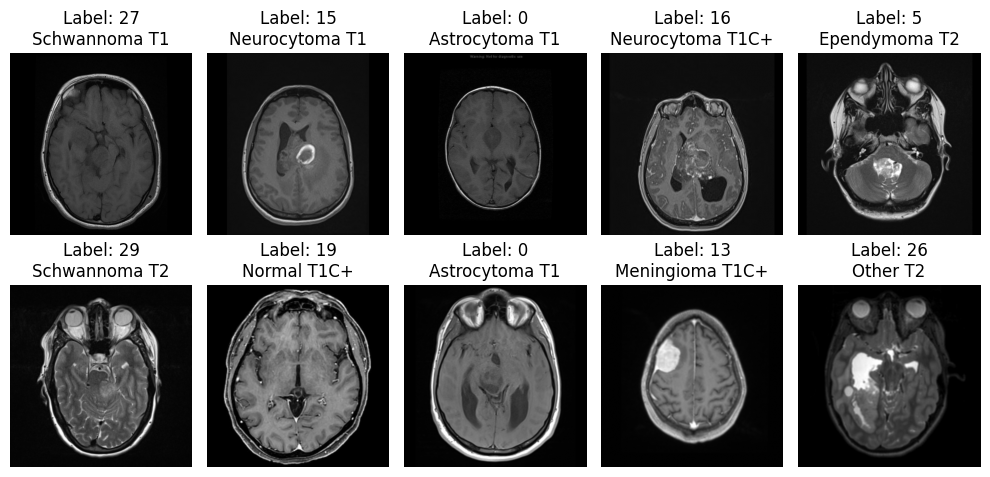



resized




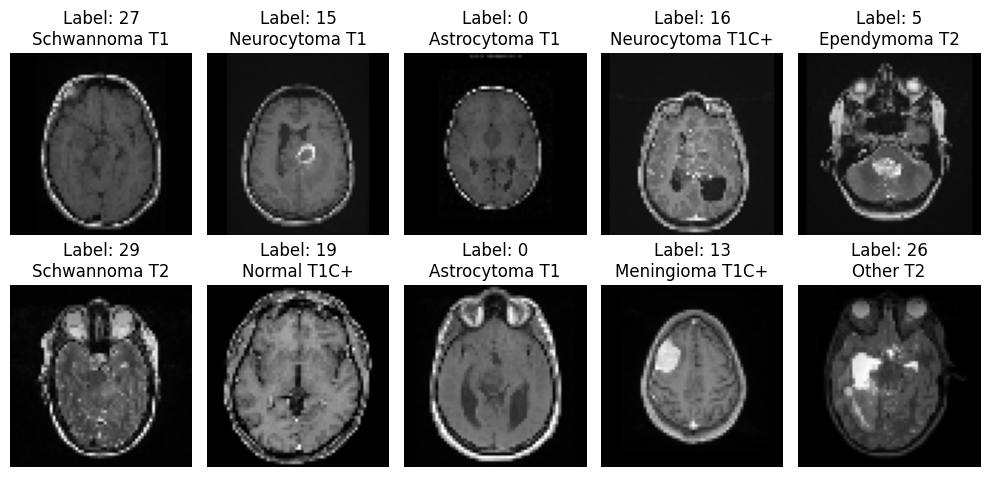

In [ ]:
import matplotlib.pyplot as plt

def display_dataset(x, y, idxs=None):
  plt.figure(figsize=(10, 5))
  if idxs is None:
      idxs = np.random.choice(len(x), 10, replace=False)
  for n, i in enumerate(idxs):
      plt.subplot(2, 5, n + 1)
      plt.imshow(x[i], cmap='gray')
      plt.title(f"Label: {y[i]}\n{class_names[y[i]]}")
      plt.axis('off')

  plt.tight_layout()
  plt.show()


idxs = np.random.choice(len(x_raw), 10, replace=False)
print("\n\noriginal\n\n")
display_dataset(x_raw, y_all,idxs)
print("\n\nresized\n\n")
display_dataset(x_all, y_all,idxs)


In [ ]:
def remove_duplicates_and_sync(x_data, y_data):
    unique_hashes = set()
    x_unique_list = []
    y_unique_list = []

    for i in range(len(x_data)):
        img = x_data[i]
        label = y_data[i]

        img_hash = img.tobytes()

        if img_hash not in unique_hashes:
            unique_hashes.add(img_hash)
            x_unique_list.append(img)
            y_unique_list.append(label)

    x_unique = np.array(x_unique_list)
    y_unique = np.array(y_unique_list)

    print(f"Original: {len(x_data)} amostras. Após remover {len(x_data) - len(x_unique)} duplicatas: {len(x_unique)} amostras.")
    print(f"remove_duplicates_and_sync: {x_unique.shape} {y_unique.shape}")

    return x_unique, y_unique

if skip_if_dataset():
    x_unique, y_unique = remove_duplicates_and_sync(x_all, y_all)



dataset ja extraido, pulado celula


In [ ]:
from sklearn.model_selection import train_test_split

if skip_if_dataset():

    x_train, x_temp, y_train, y_temp = train_test_split(
        x_unique, y_unique, test_size=0.3, random_state=42, shuffle=True
    )

    x_val, x_test, y_val, y_test = train_test_split(
        x_temp, y_temp, test_size=0.5, random_state=42, shuffle=True
    )

    print(f"\nFormato final:")
    print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
    print(f"x_val: {x_val.shape}, y_val: {y_val.shape}")
    print(f"x_test: {x_test.shape}, y_test: {y_test.shape}")

dataset ja extraido, pulado celula


In [ ]:
from imblearn.over_sampling import RandomOverSampler
import numpy as np
import pandas as pd

def get_balanced_dataset(x, y):

  n_samples, *n_features = x.shape

  x_flat = x.reshape((n_samples, np.prod(n_features)))

  ros = RandomOverSampler(random_state=42)
  x_balanced, y_balanced = ros.fit_resample(x_flat, y)

  x_balanced = x_balanced.reshape((-1, *n_features))

  df_counts = pd.DataFrame({
      'original': pd.Series(y).value_counts(),
      'balanceado': pd.Series(y_balanced).value_counts()
  }).sort_index()

  print("\nDataFrame de contagens:\n")
  print(df_counts)


  return x_balanced, y_balanced


if skip_if_dataset():

    x_train, y_train = get_balanced_dataset(x_train, y_train)
    x_val, y_val = get_balanced_dataset(x_val, y_val)
    x_test, y_test = get_balanced_dataset(x_test, y_test)
    clear_memory()


dataset ja extraido, pulado celula


In [ ]:
import numpy as np

def check_data_overlap(x_train_data, x_test_data):

    train_hashes = set()
    for img in x_train_data:
        train_hashes.add(img.tobytes())

    test_hashes = set()
    for img in x_test_data:
        test_hashes.add(img.tobytes())

    overlap = train_hashes.intersection(test_hashes)

    if len(overlap) > 0:
        print(f"ATENÇÃO: Foram encontrados {len(overlap)} elementos idênticos entre os conjuntos.")
    else:
        print("Nenhuma sobreposição encontrada entre os conjuntos.")

# Chamando a função com os dados existentes no kernel
check_data_overlap(x_train, x_val)
check_data_overlap(x_train, x_test)
check_data_overlap(x_val, x_test)


Nenhuma sobreposição encontrada entre os conjuntos.
Nenhuma sobreposição encontrada entre os conjuntos.
Nenhuma sobreposição encontrada entre os conjuntos.


In [ ]:

all_xy_arrays = {
    "x_all": x_all,

    "x_train": x_train,
    "x_val": x_val,
    "x_test": x_test,

    "y_train": y_train,
    "y_val": y_val,
    "y_test": y_test,
}

all_xy_arrays = {f"{k}_{SHAPE_X}x{SHAPE_X}":v for k,v in all_xy_arrays.items()}

all_xy_arrays = {
    "class_names":np.array(class_names),
    "x_raw": x_raw,
    "y_all": y_all,
    **all_xy_arrays
}

for key, value in all_xy_arrays.items():
    if isinstance(value, list):
        print(f"Key: {key}, Type: {type(value)}, Length: {len(value)}")
        if len(value) > 0 and hasattr(value[0], 'shape'):
            print(f"  Example element shape: {value[0].shape}")
    else:
        print(f"Key: {key}, Shape: {value.shape}")

clear_memory()

Key: class_names, Shape: ()
Key: x_raw, Shape: (11300, 512, 512)
Key: y_all, Shape: (11300,)
Key: x_all_64x64, Shape: (11300, 64, 64)
Key: x_train_64x64, Shape: (18870, 64, 64)
Key: x_val_64x64, Shape: (4350, 64, 64)
Key: x_test_64x64, Shape: (3900, 64, 64)
Key: y_train_64x64, Shape: (18870,)
Key: y_val_64x64, Shape: (4350,)
Key: y_test_64x64, Shape: (3900,)


In [ ]:
import os
import numpy as np


dataset_dir.mkdir(exist_ok=True)


for key, value in all_xy_arrays.items():
    filename = dataset_dir/f"{key}.npy"
    if not filename.exists():
        clear_memory()
        np.save(filename, value)
        clear_memory()
    print(f"Salvo '{key}' em '{filename}' com shape {value.shape}")

Salvo 'class_names' em '/content/dataset_brain_tumor/class_names.npy' com shape ()
Salvo 'x_raw' em '/content/dataset_brain_tumor/x_raw.npy' com shape (11300, 512, 512)
Salvo 'y_all' em '/content/dataset_brain_tumor/y_all.npy' com shape (11300,)
Salvo 'x_all_64x64' em '/content/dataset_brain_tumor/x_all_64x64.npy' com shape (11300, 64, 64)
Salvo 'x_train_64x64' em '/content/dataset_brain_tumor/x_train_64x64.npy' com shape (18870, 64, 64)
Salvo 'x_val_64x64' em '/content/dataset_brain_tumor/x_val_64x64.npy' com shape (4350, 64, 64)
Salvo 'x_test_64x64' em '/content/dataset_brain_tumor/x_test_64x64.npy' com shape (3900, 64, 64)
Salvo 'y_train_64x64' em '/content/dataset_brain_tumor/y_train_64x64.npy' com shape (18870,)
Salvo 'y_val_64x64' em '/content/dataset_brain_tumor/y_val_64x64.npy' com shape (4350,)
Salvo 'y_test_64x64' em '/content/dataset_brain_tumor/y_test_64x64.npy' com shape (3900,)


In [ ]:
def normalize_data(x):
    x = x.astype('float32')
    _, *axis_ = range(len(x.shape))
    axis_ = tuple(axis_)

    mean = np.mean(x, axis=axis_, keepdims=True)
    std = np.std(x, axis=axis_, keepdims=True)

    std = np.where(std == 0, 1e-7, std)

    x_norm = (x - mean) / std

    return x_norm


x_all_norm = normalize_data(x_all)

_, *axis_ = range(len(x_all_norm.shape))
axis_ = tuple(axis_)

print("\n\noriginal\n\n")
print("mean")
print_value_and_shape(np.mean(x_all, axis=axis_))
print("std")
print_value_and_shape(np.std(x_all, axis=axis_))

print("\n\nnormalizado\n\n")
print("mean")
print_value_and_shape(np.mean(x_all_norm, axis=axis_))
print("std")
print_value_and_shape(np.std(x_all_norm, axis=axis_))



original


mean

[28.32763672 50.84448242 19.22265625 ... 40.17773438 19.60375977
 30.66870117]

shape: (11300,)

std

[52.05970579 53.83167381 31.17075475 ... 49.82357696 27.59380265
 41.91780528]

shape: (11300,)



normalizado


mean

[ 0.0000000e+00  2.6077032e-08  3.7252903e-08 ...  7.4505806e-09
  3.7252903e-09 -1.3969839e-09]

shape: (11300,)

std

[1.         1.         1.         ... 1.         0.99999994 1.        ]

shape: (11300,)



In [ ]:


def get_current_data_norm():

  x_train_norm = normalize_data(x_train)
  x_val_norm = normalize_data(x_val)
  x_test_norm = normalize_data(x_test)
  x_all_norm = normalize_data(x_all)

  return x_train_norm, x_val_norm, x_test_norm, x_all_norm




def get_current_data_cnn():

  x_train_norm, x_val_norm, x_test_norm, x_all_norm = get_current_data_norm()

  x_train_cnn = x_train_norm[..., None]
  x_val_cnn = x_val_norm[..., None]
  x_test_cnn = x_test_norm[..., None]
  x_all_cnn = x_all_norm[..., None]

  return x_train_cnn, x_val_cnn, x_test_cnn, x_all_cnn




def get_current_data_transfer(preprocess_input):

  x_train_transfer = np.repeat(x_train[..., None], 3, -1)
  x_val_transfer = np.repeat(x_val[..., None], 3, -1)
  x_test_transfer = np.repeat(x_test[..., None], 3, -1)
  x_all_transfer = np.repeat(x_all[..., None], 3, -1)

  x_train_transfer = preprocess_input(x_train_transfer.astype('float32'))
  x_val_transfer = preprocess_input(x_val_transfer.astype('float32'))
  x_test_transfer = preprocess_input(x_test_transfer.astype('float32'))
  x_all_transfer = preprocess_input(x_all_transfer.astype('float32'))

  return x_train_transfer, x_val_transfer, x_test_transfer, x_all_transfer


In [ ]:
_, *x_dims = x_train.shape
num_classes = int(y_train.max()) + 1
x_dims, num_classes

([64, 64], 30)

In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
        print("TensorFlow configurado para usar GPU.")
    except RuntimeError as e:
        print(e)
else:
    print("Nenhuma GPU detectada. Vá em 'Ambiente de execução' -> 'Alterar tipo de ambiente de execução' e selecione uma GPU (T4, L4, etc).")

Nenhuma GPU detectada. Vá em 'Ambiente de execução' -> 'Alterar tipo de ambiente de execução' e selecione uma GPU (T4, L4, etc).


In [ ]:
import tensorflow as tf
import keras
from keras import layers, models, Input
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam, SGD
from pathlib import Path
from numba import cuda

def plot_model(model):
  return keras.utils.plot_model(model, expand_nested=True, show_shapes=True, show_layer_activations=True)

def show_model(model):
    def save_str(x):
      Path("model.txt").write_text(str(x))
    model.summary(print_fn=save_str)
    plot_model(model)


def get_best_model(x_val_inp, x_test_inp):
  model = models.load_model(checkpoint_filepath)
  show_model(model)
  print("validação")
  eval(model, x_val_inp, y_val)
  print()
  print()
  print("teste")
  eval(model, x_test_inp, y_test)
  return model

def eval(model, x_inp, y_inp):
  loss, acc = model.evaluate(x_inp, y_inp)
  print(f"\nAcurácia da CNN no conjunto: {acc:.4f}")



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from threading import Thread
from pathlib import Path

def plot_history(history, save_path=None):
    def _generate_plots(hist_dict, path):
        max_acc = max(hist_dict['val_accuracy']) if 'val_accuracy' in hist_dict else 0
        min_loss = min(hist_dict['val_loss']) if 'val_loss' in hist_dict else 0
        title_text = f"Max Val Acc: {max_acc:.4f} | Min Val Loss: {min_loss:.4f}"

        fig = plt.figure(figsize=(12, 5))
        plt.suptitle(title_text)

        plt.subplot(1, 2, 1)
        if 'accuracy' in hist_dict: plt.plot(hist_dict['accuracy'], label='Training Accuracy', color='blue')
        if 'val_accuracy' in hist_dict: plt.plot(hist_dict['val_accuracy'], label='Validation Accuracy', color='orange')
        plt.title('Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        if 'loss' in hist_dict: plt.plot(hist_dict['loss'], label='Training Loss', color='blue')
        if 'val_loss' in hist_dict: plt.plot(hist_dict['val_loss'], label='Validation Loss', color='orange')
        plt.title('Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)

        plt.tight_layout(rect=[0, 0, 1, 0.95])

        if path:
            plt.savefig(f"{path}.png")
            plt.close(fig)
        else:
            plt.show()

        epochs = list(range(1, len(hist_dict['loss']) + 1))
        fig_plotly = make_subplots(
            rows=1, cols=2,
            subplot_titles=("Accuracy", "Loss"),
            horizontal_spacing=0.1
        )

        if 'accuracy' in hist_dict:
            fig_plotly.add_trace(go.Scatter(x=epochs, y=hist_dict['accuracy'], mode='lines+markers', name='Training Accuracy', line=dict(color='blue'), hoverinfo='y'), row=1, col=1)
        if 'val_accuracy' in hist_dict:
            fig_plotly.add_trace(go.Scatter(x=epochs, y=hist_dict['val_accuracy'], mode='lines+markers', name='Validation Accuracy', line=dict(color='orange'), hoverinfo='y'), row=1, col=1)
        if 'loss' in hist_dict:
            fig_plotly.add_trace(go.Scatter(x=epochs, y=hist_dict['loss'], mode='lines+markers', name='Training Loss', line=dict(color='blue'), hoverinfo='y'), row=1, col=2)
        if 'val_loss' in hist_dict:
            fig_plotly.add_trace(go.Scatter(x=epochs, y=hist_dict['val_loss'], mode='lines+markers', name='Validation Loss', line=dict(color='orange'), hoverinfo='y'), row=1, col=2)

        fig_plotly.update_layout(
            title_text=title_text,
            title_x=0.5,
            showlegend=True,
            hovermode='closest',
            hoverdistance=100,
            spikedistance=100
        )

        if path:
            fig_plotly.write_html(f"{path}.html", include_plotlyjs='cdn')
        else:
            fig_plotly.show()

    hist_data = {k: list(v) for k, v in history.history.items()}

    if save_path is not None:
        p = Path(save_path)
        base_path = str(p.parent / p.stem)
        Thread(target=_generate_plots, args=(hist_data, base_path), daemon=True).start()
    else:
        _generate_plots(hist_data, None)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def get_confusion_matrix_normalized(model, current_x_test):
  y_pred_probs = model.predict(current_x_test)
  y_pred = np.argmax(y_pred_probs, axis=1)

  cm = confusion_matrix(y_test, y_pred)

  row_sums = cm.sum(axis=1)
  cm_normalized = cm.astype('float') / (row_sums[:, np.newaxis] + 1e-8)

  cm_normalized = cm_normalized * 100

  return cm_normalized



def plot_confusion_matrix(cm_normalized):

  fig, ax = plt.subplots(figsize=(15, 15))
  disp = ConfusionMatrixDisplay(
      confusion_matrix=cm_normalized,
      display_labels=list(class_names.values())
  )
  disp.plot(
      cmap=plt.cm.Blues,
      ax=ax,
      xticks_rotation='vertical',
      values_format='.0f',
      text_kw={"fontsize": 8}
  )
  plt.title('Normalized Confusion Matrix (Accuracy per Class - Percentage)', fontsize=14)
  plt.xlabel('Predicted label', fontsize=12)
  plt.ylabel('True label', fontsize=12)
  plt.show()



def get_min_acc_class(cm_normalized):
  class_acc = np.diag(cm_normalized)

  max_acc_idx = np.argmax(class_acc)
  min_acc_idx = np.argmin(class_acc)

  max_acc_class_name = class_names[max_acc_idx]
  max_acc = class_acc[max_acc_idx]
  min_acc_class_name = class_names[min_acc_idx]
  min_acc = class_acc[min_acc_idx]

  print(f"Classe com maior acurácia: {max_acc_class_name} ({max_acc:.2f}%)")
  print(f"Classe com menor acurácia: {min_acc_class_name} ({min_acc:.2f}%)")
  print(f"média das acurácias por classe: {class_acc.mean():.2f}%")
  print(f"desvio padrão das acurácias por classe: {class_acc.std():.2f}%")

  return min_acc_idx, min_acc_class_name, min_acc


def plot_class_acc_distribution(cm_normalized):
  class_acc = np.diag(cm_normalized)

  plt.figure(figsize=(15, 7))
  plt.bar(list(class_names.values()), class_acc, color='skyblue')
  plt.xlabel('Classes')
  plt.ylabel('Acurácia (%)')
  plt.title('Acurácia por Classe')
  plt.xticks(rotation=90, fontsize=8)
  plt.tight_layout()
  plt.show()


def show_min_acc_distribution(cm_normalized, min_acc_idx, min_acc_class_name, min_acc):
  confused_row = cm_normalized[min_acc_idx]

  confused_row_new = cm_normalized[min_acc_idx].copy()

  confused_row_new[min_acc_idx] = 0

  most_confused_idx = np.argmax(confused_row_new)

  most_confused_class_name = class_names[most_confused_idx]
  confusion_percentage = confused_row[most_confused_idx]

  print(f"A classe '{min_acc_class_name}' (com {min_acc:.2f}% de acurácia) está se confundindo mais com '{most_confused_class_name}', com {confusion_percentage:.2f}% dos casos.")

  bar_colors = ['lightcoral'] * len(class_names)
  for i, class_name_val in class_names.items():
      if class_name_val == min_acc_class_name:
          bar_colors[i] = 'skyblue'
          break

  plt.figure(figsize=(15, 7))
  plt.bar(list(class_names.values()), confused_row, color=bar_colors)
  plt.xlabel('Classes Preditas')
  plt.ylabel('Percentual de Confusão (%)')
  plt.title(f"Confusão da Classe '{min_acc_class_name}' com Outras Classes")
  plt.xticks(rotation=90, fontsize=8)
  plt.tight_layout()
  plt.show()

In [ ]:
import tensorflow as tf
from keras import layers, models, Input
import numpy as np

def get_heatmap_model(model, x_inp):
    gap_layer = None
    gap_idx = None
    for idx, layer in enumerate(model.layers):
        if isinstance(layer, (layers.GlobalAveragePooling2D, layers.GlobalMaxPooling2D)):
            gap_layer = layer
            gap_idx = idx
            break
    if gap_idx is None:
        raise ValueError("Nenhuma camada GlobalAveragePooling2D/GlobalMaxPooling2D encontrada.")
    if gap_idx == 0:
        raise ValueError("A camada de pooling é a primeira camada do modelo.")

    pre_pool_layer = model.layers[gap_idx - 1]

    dense_layers = [layer for layer in model.layers if isinstance(layer, layers.Dense)]
    if not dense_layers:
        raise ValueError("Nenhuma camada Dense encontrada.")

    heatmap_input_tensor = model.input

    base_model_for_heatmap = models.Model(inputs=heatmap_input_tensor, outputs=pre_pool_layer.output)
    x = base_model_for_heatmap(heatmap_input_tensor)

    for i, dense in enumerate(dense_layers):
        kernel, bias = dense.get_weights()
        out_dim = kernel.shape[1]
        kernel_4d = np.reshape(kernel, (1, 1, kernel.shape[0], out_dim))

        activation = dense.activation
        if i == len(dense_layers) - 1:
            activation = tf.keras.activations.linear

        conv = layers.Conv2D(
            out_dim, (1, 1),
            use_bias=True,
            kernel_initializer=tf.constant_initializer(kernel_4d),
            bias_initializer=tf.constant_initializer(bias),
            activation=activation,
            trainable=False,
            name=f'spatial_dense_{i}'
        )
        x = conv(x)

    probs = model(heatmap_input_tensor)

    heatmap_model = models.Model(inputs=heatmap_input_tensor, outputs=[x, probs], name='heatmap_all_classes')
    print("saidas:", [i.shape for i in heatmap_model(x_inp[0][None,...])])
    return heatmap_model




In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def display_heatmaps_line(idx, x_norm_data, x_raw_data, y_labels, heatmap_model, n_display_probs=5):
    img_norm = x_norm_data[idx]

    img_tensor = img_norm[None,...]

    all_heatmaps, probs = heatmap_model(img_tensor)
    all_heatmaps = all_heatmaps[0].numpy()
    probs_flat = probs[0].numpy()
    num_classes = all_heatmaps.shape[-1]

    global_min = all_heatmaps.min()
    global_max = all_heatmaps.max()

    pred_class = np.argmax(probs_flat);
    true_class = y_labels[idx]

    prediction_color = 'blue' if pred_class == true_class else 'red'

    sorted_prob_indices = np.argsort(probs_flat)[::-1]

    indices_to_plot_set = set()
    indices_to_plot_set.add(true_class)
    indices_to_plot_set.add(pred_class)

    for i in range(min(n_display_probs, num_classes)):
        indices_to_plot_set.add(sorted_prob_indices[i])

    bottom_n_indices = np.argsort(probs_flat)
    count_added = 0
    for i in range(num_classes):
        if bottom_n_indices[i] not in indices_to_plot_set:
            indices_to_plot_set.add(bottom_n_indices[i])
            count_added += 1
        if count_added >= n_display_probs:
            break

    indices_to_plot = sorted(list(indices_to_plot_set), key=lambda k: probs_flat[k], reverse=True)
    num_plots = len(indices_to_plot) + 1

    img_raw = x_raw_data[idx]
    h, w = img_raw.shape

    fig_width = 4 * num_plots
    plt.figure(figsize=(fig_width, 4))

    plt.subplot(1, num_plots, 1)
    plt.imshow(img_raw, cmap='gray')
    plt.title(f"Original\nTrue: {class_names[true_class]} ({true_class})", color='black')
    plt.axis('off')

    for i, k in enumerate(indices_to_plot):
        heatmap = all_heatmaps[:, :, k]
        heatmap_resized = cv2.resize(heatmap, (w, h))
        heatmap_norm = (heatmap_resized - global_min) / (global_max - global_min + 1e-8)

        plt.subplot(1, num_plots, i + 2)
        plt.imshow(img_raw, cmap='gray')
        plt.imshow(heatmap_norm, cmap='jet', alpha=0.4, vmin=0, vmax=1)

        if pred_class != true_class and k == true_class:
            title_color = 'green'
        elif k == pred_class:
            title_color = prediction_color
        else:
            title_color = 'black'

        plt.title(f"Class: {class_names[k]}\nProb: {probs_flat[k]:.2f}", color=title_color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

def display_heatmaps(current_x_all, x_raw, y_all, model_heatmap, n_display_probs=2):
  random_indices = np.random.choice(len(current_x_all), 10, replace=False)
  for idx in random_indices:
      display_heatmaps_line(idx, current_x_all, x_raw, y_all, model_heatmap, n_display_probs)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def show_model_predictions(model, x_test_inp):
  random_indices = np.random.choice(len(x_test_inp), 10, replace=False)

  x_test_display = x_test[random_indices]
  x_test_predict = x_test_inp[random_indices]
  y_test_display = y_test[random_indices]

  predictions = model.predict(x_test_predict)

  plt.figure(figsize=(12, 6))
  for i in range(10):
      plt.subplot(2, 5, i + 1)
      plt.imshow(x_test_display[i], cmap='gray')

      predicted_label = np.argmax(predictions[i])
      true_label = y_test_display[i]

      color = 'blue' if predicted_label == true_label else 'red'

      plt.title(f"Real: {class_names[true_label]}\nPred: {class_names[predicted_label]}", color=color, fontsize=10)
      plt.axis('off')

  plt.tight_layout()
  plt.show()

In [ ]:
from keras import mixed_precision
import numpy as np

mixed_precision.set_global_policy('mixed_float16')

tf.config.optimizer.set_jit(True)
tf.config.optimizer.set_experimental_options({
    'layout_optimizer': True,
    'constant_folding': True,
    'shape_optimization': True,
    'remapping': True
})



In [ ]:
# from IPython.display import IFrame

# print(f"Acessando servidor em: {public_url}")

# IFrame(src=public_url, width='100%', height=600)

In [ ]:

def get_model_checkpoint_callback(checkpoint_filepath:Path):

  model_checkpoint_callback = ModelCheckpoint(
      filepath=checkpoint_filepath,
      save_best_only=True,
      monitor='val_accuracy',
      mode='max',
  )

  return model_checkpoint_callback

checkpoint_filepath = Path('best_model_cnn.keras')

if not checkpoint_filepath.exists():
  model_checkpoint_callback = get_model_checkpoint_callback(checkpoint_filepath)


def build_cnn_model(make_model_func, num_colors = 1):
    clear_memory()
    model = make_model_func(Input(shape=(SHAPE_X, SHAPE_X, num_colors)))
    show_model(model)
    model = make_model_func(Input(shape=(None, None, num_colors)))
    clear_memory()
    cosine_restarts = keras.optimizers.schedules.CosineDecayRestarts(
        initial_learning_rate=0.01,      # LR inicial (pico do 1º ciclo)
        first_decay_steps=10,            # épocas até o primeiro reinício
        t_mul=2.0,                       # multiplica o período a cada ciclo
        m_mul=0.8,                       # multiplica a LR máxima a cada ciclo
        alpha=0.0001                     # LR mínima como fração de initial_lr (0.0001*0.01 = 1e-6)
    )
    model.compile(
        optimizer=Adam(learning_rate=cosine_restarts),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
        jit_compile=True
        )
    return model


def update_history(history, current_epoch, logs):
    for key, val in logs.items():
        if key not in history.history: history.history[key] = []
        if isinstance(val, list):
            history.history[key].extend(val)
        else:
            history.history[key].append(val)

    scalar_logs = {k: (v[0] if isinstance(v, list) else v) for k, v in logs.items()}
    model_checkpoint_callback.on_epoch_end(epoch=current_epoch, logs=scalar_logs)




In [ ]:
def fit(model, x_train_inp, x_val_inp, history, epochs=30):

    model_checkpoint_callback.set_model(model)
    model_checkpoint_callback.on_train_begin()

    for i in range(epochs):
        print(f"\nEpoch {i+1}/{epochs}")
        model_checkpoint_callback.on_epoch_begin(epoch=i)

        # x_with_noise, y_with_noise = add_noise_class(x_train_inp, y_train)

        current_history = model.fit(
            x_train_inp, y_train,
            epochs=i + 1,
            initial_epoch=i,
            validation_data=(x_val_inp, y_val),
            callbacks=[],
            verbose=1
        )
        update_history(history, i, current_history.history)

        plot_history(history, save_path='history.png')

    model_checkpoint_callback.on_train_end()

In [ ]:
import json
from google.colab import _message
from pathlib import Path
# 1. Obtém o conteúdo JSON do notebook da memória do navegador
notebook_data = _message.blocking_request('get_ipynb', timeout_sec=5)
content = notebook_data.get('ipynb', {})

# 2. Extrai apenas o código fonte das células de código
python_code = []
for cell in content.get('cells', []):
    if cell['cell_type'] == 'code':
        # Adiciona um marcador para separar as células ou comentários
        python_code.append(f"# Cell: {cell.get('id', 'unknown')}\n")
        python_code.append(''.join(cell['source']))
        python_code.append('\n\n') # Adiciona duas novas linhas para separação clara

# 3. Define o caminho físico para o arquivo .py
path = Path("/content/notebook.py")

# 4. Salva o conteúdo filtrado (apenas código Python) no disco
with open(path, 'w') as f:
    f.write(''.join(python_code))

path


PosixPath('/content/notebook.py')

In [ ]:
raise Exception("parada forçada")

Exception: parada forçada

In [ ]:
# tf.keras.layers.RandomFlip(),
# tf.keras.layers.RandomRotation(factor=0.5),

In [ ]:

def make_model(inputs):
  # x = layers.Conv2D(1, (1, 1), activation='relu')(inputs)
  x = layers.GlobalAveragePooling2D()(inputs)
  outputs = layers.Dense(num_classes, activation='softmax')(x)

  model = models.Model(inputs=inputs, outputs=outputs)
  return model

current_x_train, current_x_val, current_x_test, current_x_all = get_current_data_cnn()

history = keras.callbacks.History()

model_temp = build_cnn_model(make_model)

model_checkpoint_callback = get_model_checkpoint_callback(checkpoint_filepath)

#0.8856

In [ ]:
#CNN PADRÃO
def make_model(inputs):
  x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D((2, 2))(x)

  x = layers.Conv2D(64, (3, 3), activation='relu')(x)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D((2, 2))(x)

  x = layers.Conv2D(128, (3, 3), activation='relu')(x)
  x = layers.BatchNormalization()(x)
  x = layers.GlobalAveragePooling2D()(x)

  x = layers.Dense(256, activation='relu')(x)
  x = layers.Dropout(0.5)(x)
  outputs = layers.Dense(num_classes, activation='softmax')(x)

  model = models.Model(inputs=inputs, outputs=outputs)
  return model

current_x_train, current_x_val, current_x_test, current_x_all = get_current_data_cnn()

history = keras.callbacks.History()

model_temp = build_cnn_model(make_model)

model_checkpoint_callback = get_model_checkpoint_callback(checkpoint_filepath)

#0.8856


In [ ]:
# Iniciar o processo de treinamento com monitoramento em tempo real
fit(model_temp, current_x_train, current_x_val, history, epochs=90)


Epoch 1/90
590/590 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0314 - loss: 3.4026 - val_accuracy: 0.0333 - val_loss: 3.4013

Epoch 2/90
Epoch 2/2
590/590 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.0303 - loss: 3.4020 - val_accuracy: 0.0333 - val_loss: 3.4013

Epoch 3/90
Epoch 3/3
590/590 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0307 - loss: 3.4019 - val_accuracy: 0.0333 - val_loss: 3.4013

Epoch 4/90
Epoch 4/4
590/590 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0311 - loss: 3.4016 - val_accuracy: 0.0333 - val_loss: 3.4012

Epoch 5/90
Epoch 5/5
590/590 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0318 - loss: 3.4016 - val_accuracy: 0.0333 - val_loss: 3.4013

Epoch 6/90
Epoch 6/6
590/590 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0303 - loss: 3.4019 - val_accuracy: 0.0333 - val_loss: 3.4012

Epoch 7/90
Epoch 7/7
590/590 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.0284 - loss: 3.4016 - val_accuracy: 0.0333 - val_loss: 3.4012

Epoch 8/90
Epoch 8/8
590/590 ━━━━━━━

In [ ]:
model_temp.optimizer.learning_rate.numpy()

In [ ]:
plot_history(history)

In [ ]:
model = get_best_model(current_x_val, current_x_test)

In [ ]:

def layer(x, filters=32, kernel_size_list=[5,7, 9]):
  filters = int(filters / len(kernel_size_list))
  outs = [layers.Conv2D(filters, (i, i), activation='relu', padding="same")(x) for i in kernel_size_list]
  outs = layers.Concatenate()(outs)
  return outs

def make_model(inputs):
  x = layer(inputs)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D((2, 2))(x)

  x = layer(x, 64)
  x = layers.BatchNormalization()(x)
  x = layers.MaxPooling2D((2, 2))(x)

  x = layer(x, 128)
  x = layers.BatchNormalization()(x)
  x = layers.GlobalAveragePooling2D()(x)

  x = layers.Dense(256, activation='relu')(x)
  x = layers.Dropout(0.5)(x)
  outputs = layers.Dense(num_classes, activation='softmax')(x)

  model = models.Model(inputs=inputs, outputs=outputs)
  return model

current_x_test = x_test_cnn

history = keras.callbacks.History()

model_temp = build_cnn_model(make_model)

model_checkpoint_callback, reduce_lr = get_model_checkpoint_callback(checkpoint_filepath)


#0.9078


In [ ]:

def layer(x, filters=32, kernel_size_list=[5,7, 9], conv_class=layers.Conv2D):
  filters = int(filters / len(kernel_size_list))
  outs = [conv_class(filters, (i, i), activation='relu', padding="same")(x) for i in kernel_size_list]
  outs = layers.Concatenate()(outs)
  return outs

def block(inputs, filters=32, kernel_size_list=[5,7, 9], conv_class=layers.Conv2D):
  filters = int(filters / len(kernel_size_list)) * len(kernel_size_list)

  x = layer(inputs, filters, kernel_size_list, conv_class)
  # x = layer(x, filters, kernel_size_list)
  x2 = layers.Conv2D(filters, (1, 1), activation='relu', padding="same")(inputs)
  x = layers.Add()([x,x2])
  x = layers.BatchNormalization()(x)
  return x

def make_model(inputs):
  x = inputs
  x = block(x, 32, conv_class=layers.Conv2D)
  x = block(x, 32, conv_class=layers.SeparableConv2D)
  x = layers.MaxPooling2D((2, 2))(x)

  x = block(x, 64, conv_class=layers.Conv2D)
  x = block(x, 64, conv_class=layers.SeparableConv2D)
  x = layers.MaxPooling2D((2, 2))(x)

  x = block(x, 128,  conv_class=layers.Conv2D)
  x = block(x, 128,  conv_class=layers.SeparableConv2D)
  x = layers.GlobalAveragePooling2D()(x)

  x = layers.Dense(256, activation='relu')(x)
  x = layers.Dropout(0.5)(x)
  outputs = layers.Dense(num_classes, activation='softmax')(x)

  model = models.Model(inputs=inputs, outputs=outputs)
  return model

current_x_train, current_x_val, current_x_test, current_x_all = get_current_data_cnn()

history = keras.callbacks.History()

model_temp = build_cnn_model(make_model)

model_checkpoint_callback, reduce_lr = get_model_checkpoint_callback(checkpoint_filepath)

#0.9392

In [ ]:
import tensorflow as tf
from keras import layers, models, Input
from keras.callbacks import ModelCheckpoint


def make_model(inputs):

    x = layers.SeparableConv2D(32, (3, 3), activation='relu', padding="same")(inputs)
    x = layers.SeparableConv2D(32, (3, 3), activation='relu', padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.SeparableConv2D(64, (3, 3), activation='relu', padding="same")(x)
    x = layers.SeparableConv2D(64, (3, 3), activation='relu', padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.SeparableConv2D(128, (3, 3), activation='relu', padding="same")(x)
    x = layers.SeparableConv2D(128, (3, 3), activation='relu', padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

current_x_test = x_test_cnn

history = keras.callbacks.History()

model_temp = build_cnn_model(make_model)

model_checkpoint_callback, reduce_lr = get_model_checkpoint_callback(checkpoint_filepath)


In [ ]:
import tensorflow as tf
from keras import layers, models, Input
from keras.callbacks import ModelCheckpoint

def residual_block(x, filters, kernel_size=(3, 3), stride=1, activate_before_res=False):
    """
    Um bloco residual que pode ser usado para construir uma ResNet.
    """
    # A função de identidade passa a entrada sem modificações
    shortcut = x

    # Camada de normalização e ativação antes do bloco convolucional, se especificado
    if activate_before_res:
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

    # Primeira convolução
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Segunda convolução
    x = layers.Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)

    # Se as dimensões da entrada e saída do atalho não corresponderem (por causa do stride),
    # fazemos uma convolução 1x1 no atalho para corresponder às dimensões.
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same', kernel_initializer='he_normal')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Adiciona o atalho à saída do bloco e aplica a ativação final
    x = layers.add([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def make_model(inputs):

      # Camada de entrada
      x = layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal')(inputs)
      x = layers.BatchNormalization()(x)
      x = layers.Activation('relu')(x)
      x = layers.MaxPooling2D((2, 2))(x)

      # Blocos Residuais
      x = residual_block(x, 64) # Bloco sem downsampling
      x = residual_block(x, 64) # Outro bloco sem downsampling
      x = residual_block(x, 128, stride=2) # Bloco com downsampling
      x = residual_block(x, 128)

      # x = residual_block(x, 32)
      # x = residual_block(x, 32)
      # x = residual_block(x, 32)
      # x = residual_block(x, 32)

      # Camada final de pooling e classificação
      x = layers.GlobalAveragePooling2D()(x)

      x = layers.Dense(256, activation='relu')(x)
      x = layers.Dropout(0.5)(x)
      outputs = layers.Dense(num_classes, activation='softmax')(x)

      model = models.Model(inputs=inputs, outputs=outputs)
      return model

current_x_test = x_test_cnn

history = keras.callbacks.History()

model_temp = build_cnn_model(make_model)

model_checkpoint_callback = get_model_checkpoint_callback(checkpoint_filepath)



In [ ]:
from keras.applications import VGG16
from keras.applications.vgg16 import preprocess_input
from keras import layers, models
import numpy as np


def make_model(inputs):
  base_model = VGG16(weights='imagenet', include_top=False, input_tensor=inputs, name="base_model")
  base_model.trainable = False

  x = base_model(inputs)
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.Dense(256, activation='relu')(x)
  x = layers.Dropout(0.5)(x)
  x = layers.Dense(num_classes, activation='softmax')(x)

  model = models.Model(inputs=inputs, outputs=x)
  return model


current_x_train, current_x_val, current_x_test, current_x_all = get_current_data_transfer(preprocess_input)

history = keras.callbacks.History()

model_temp = build_cnn_model(make_model, num_colors=3)

model_checkpoint_callback, reduce_lr = get_model_checkpoint_callback(checkpoint_filepath)

In [ ]:
fit(model_temp, current_x_train, current_x_val, history, epochs=30, steps=1)

In [ ]:
model = get_best_model(current_x_val, current_x_test)

In [ ]:
show_model_predictions(model, current_x_test)

In [ ]:
cm_normalized = get_confusion_matrix_normalized(model, current_x_test)
plot_confusion_matrix(cm_normalized)

In [ ]:
min_acc_idx, min_acc_class_name, min_acc = get_min_acc_class(cm_normalized)
plot_class_acc_distribution(cm_normalized)

In [ ]:
show_min_acc_distribution(cm_normalized, min_acc_idx, min_acc_class_name, min_acc)

In [ ]:
model_heatmap = get_heatmap_model(model, current_x_all)
display_heatmaps(current_x_all, x_raw, y_all, model_heatmap)

In [ ]:
base = next(i for i in model_temp.layers if i.name == "base_model")
base.trainable = True

In [ ]:
import tensorflow as tf
from keras import layers, models


model = models.Sequential([
    layers.Flatten(input_shape=x_dims),          # Transforma a imagem 28x28 em um vetor de 784 pixels
    layers.Dense(128, activation='relu'),          # Camada oculta com 128 neurônios
    layers.Dropout(0.2),                           # Camada de regularização para evitar overfitting
    layers.Dense(y_dims, activation='softmax')         # Camada de saída com 10 neurônios (0 a 9)
])

# 3. Compilar o modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Treinar o modelo
model.fit(x_train_norm, y_train_norm, epochs=5)

model.evaluate(x_test_norm, y_test_norm)

In [ ]:
import tensorflow as tf
from keras import layers, models
from keras.applications.convnext import preprocess_input, ConvNeXtBase
import keras

x_train_transfer_raw = np.repeat(x_train_balanced[..., np.newaxis], 3, -1)
x_test_transfer_raw = np.repeat(x_test_balanced[..., np.newaxis], 3, -1)

x_train_transfer = preprocess_input(x_train_transfer_raw.astype('float32'))
x_test_transfer = preprocess_input(x_test_transfer_raw.astype('float32'))
y_train_transfer = y_train_balanced
y_test_transfer = y_test_balanced

x_transfer_dim = x_train_transfer.shape[1:]
# Carrega o ConvNeXtBase sem o topo, com pesos ImageNet
base_model = ConvNeXtBase(
    include_top=False,
    weights='imagenet',
    input_shape=x_transfer_dim,
    pooling='avg'  # adiciona global average pooling no lugar do topo
)

# Congela a base
base_model.trainable = False

# Adiciona suas camadas de classificação
model = models.Sequential([
    base_model,
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(y_dims, activation='softmax')
])


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("--- Treinando Transfer Learning com preprocess_input correto ---")
model.fit(x_train_transfer, y_train_transfer, epochs=15, batch_size=32, validation_data=(x_test_transfer, y_test_transfer))

# Avaliação final
loss, acc = model.evaluate(x_test_transfer, y_test_transfer)
print(f"\nAcurácia final com transfer16: {acc:.4f}")